In [3]:
!pip install yfinance
!pip install pandas
!pip install numpy
!pip install plotly
!pip install scipy
!pip install statsmodels
!pip install pyarrow
!pip install duckdb
!pip install tqdm

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.express as px
import matplotlib.pyplot as plt
import duckdb
import warnings

warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [5]:
apple = yf.download(
    "AAPL",
    start="2024-01-01"
)

print(apple.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  183.562180  186.330843  181.831767  185.055273  82488700
2024-01-03  182.187744  183.799505  181.376915  182.158081  58414500
2024-01-04  179.873932  181.040717  178.855462  180.111236  71983600
2024-01-05  179.152100  180.714417  178.153410  179.953046  62379700
2024-01-08  183.483078  183.522639  179.468523  180.051916  59144500


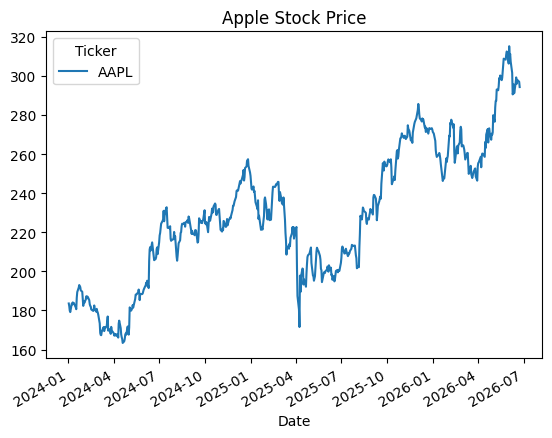

In [6]:
apple["Close"].plot()

plt.title("Apple Stock Price")

plt.show()

In [7]:
# Small starter universe
stocks = [

    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL",

    "META",
    "JPM",
    "BAC",
    "GS",
    "TSLA"

]

print(stocks)
print("Universe Size:", len(stocks))

['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'JPM', 'BAC', 'GS', 'TSLA']
Universe Size: 10


In [8]:
prices = yf.download(

    stocks,

    start="2023-01-01",

    auto_adjust=True

)["Close"]

prices.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,BAC,GOOGL,GS,JPM,META,MSFT,NVDA,TSLA
Date,,,,,,,,,,
2023-01-03,122.982719,85.820000,30.640945,88.336700,318.011688,124.292610,123.654121,232.948273,14.283263,108.099998
2023-01-04,124.251183,85.139999,31.217009,87.305824,319.371094,125.451637,126.261238,222.758347,14.716301,113.639999
2023-01-05,122.933540,83.120003,31.153000,85.442368,315.752136,125.423859,125.834976,216.156265,14.233374,110.339996
2023-01-06,127.456772,86.080002,31.463896,86.572334,319.720154,127.823883,128.888153,218.703781,14.826058,113.059998
2023-01-09,127.977928,87.360001,30.988407,87.246361,324.239227,127.295692,128.342957,220.833160,15.593350,119.769997


In [9]:
returns = prices.pct_change()

returns.head()

Ticker,AAPL,AMZN,BAC,GOOGL,GS,JPM,META,MSFT,NVDA,TSLA
Date,,,,,,,,,,
2023-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-04,0.010314,-0.007924,0.018800,-0.011670,0.004275,0.009325,0.021084,-0.043743,0.030318,0.051249
2023-01-05,-0.010605,-0.023726,-0.002050,-0.021344,-0.011332,-0.000221,-0.003376,-0.029638,-0.032816,-0.029039
2023-01-06,0.036794,0.035611,0.009980,0.013225,0.012567,0.019135,0.024263,0.011786,0.041640,0.024651
2023-01-09,0.004089,0.014870,-0.015112,0.007786,0.014134,-0.004132,-0.004230,0.009736,0.051753,0.059349


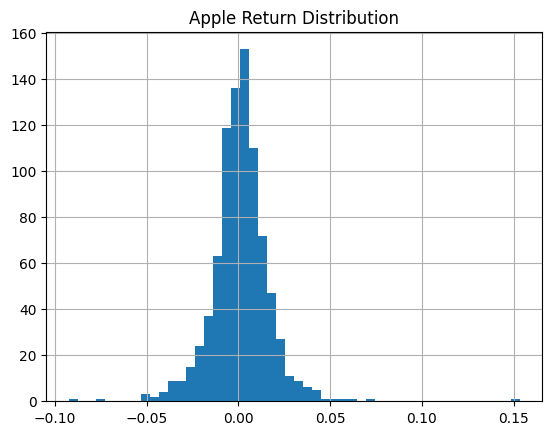

In [10]:
returns["AAPL"].hist(
    bins=50
)

plt.title(
    "Apple Return Distribution"
)

plt.show()

In [11]:
# ======================================
# MOMENTUM FACTOR
# ======================================

momentum = prices.pct_change(30)

momentum.tail()

Ticker,AAPL,AMZN,BAC,GOOGL,GS,JPM,META,MSFT,NVDA,TSLA
Date,,,,,,,,,,
2026-06-16,0.081948,-0.095754,0.094756,-0.025511,0.212790,0.076353,-0.015799,-0.045784,0.046210,0.030955
2026-06-17,0.042377,-0.131786,0.069724,-0.062875,0.201432,0.077763,-0.060920,-0.076935,0.042690,0.018003
2026-06-18,0.037475,-0.111277,0.053955,-0.074842,0.175007,0.032772,-0.057311,-0.081501,0.014943,0.004414
2026-06-22,0.034246,-0.141535,0.093234,-0.120860,0.200218,0.082313,-0.085014,-0.125091,-0.012325,-0.016368
2026-06-23,0.004265,-0.141448,0.134494,-0.135886,0.173825,0.106058,-0.076947,-0.097249,-0.069363,-0.109116


In [12]:
latest_momentum = momentum.iloc[-1]

print(latest_momentum)


Ticker
AAPL     0.004265
AMZN    -0.141448
BAC      0.134494
GOOGL   -0.135886
GS       0.173825
JPM      0.106058
META    -0.076947
MSFT    -0.097249
NVDA    -0.069363
TSLA    -0.109116
Name: 2026-06-23 00:00:00, dtype: float64


In [13]:
ranked = latest_momentum.sort_values(
    ascending=False
)

print(ranked)

Ticker
GS       0.173825
BAC      0.134494
JPM      0.106058
AAPL     0.004265
NVDA    -0.069363
META    -0.076947
MSFT    -0.097249
TSLA    -0.109116
GOOGL   -0.135886
AMZN    -0.141448
Name: 2026-06-23 00:00:00, dtype: float64


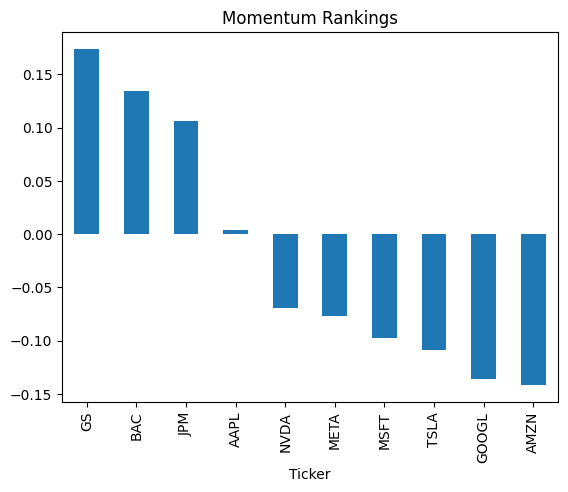

In [14]:
ranked.plot(
    kind="bar"
)

plt.title(
    "Momentum Rankings"
)

plt.show()

In [16]:
top_stocks = ranked.head(3)

print(top_stocks)

Ticker
GS     0.173825
BAC    0.134494
JPM    0.106058
Name: 2026-06-23 00:00:00, dtype: float64


In [17]:
portfolio_weights = {}

for stock in top_stocks.index:

    portfolio_weights[stock] = 1/3

print(portfolio_weights)




{'GS': 0.3333333333333333, 'BAC': 0.3333333333333333, 'JPM': 0.3333333333333333}


In [18]:
portfolio_returns = returns[
    top_stocks.index
]

portfolio_returns.head()


Ticker,GS,BAC,JPM
Date,,,
2023-01-03,NaN,NaN,NaN
2023-01-04,0.004275,0.018800,0.009325
2023-01-05,-0.011332,-0.002050,-0.000221
2023-01-06,0.012567,0.009980,0.019135
2023-01-09,0.014134,-0.015112,-0.004132


In [19]:
strategy_returns = portfolio_returns.mean(
    axis=1
)

strategy_returns.head()


,0
Date,
2023-01-03,NaN
2023-01-04,0.010800
2023-01-05,-0.004534
2023-01-06,0.013894
2023-01-09,-0.001703


In [20]:
equity_curve = (

    1 + strategy_returns

).cumprod()

equity_curve.head()


,0
Date,
2023-01-03,NaN
2023-01-04,1.010800
2023-01-05,1.006217
2023-01-06,1.020197
2023-01-09,1.018459


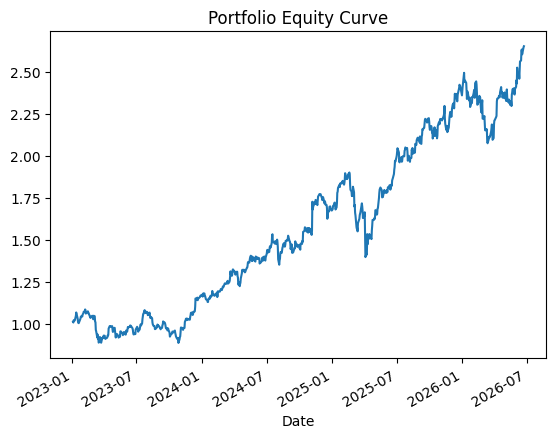

In [21]:
equity_curve.plot()

plt.title(
    "Portfolio Equity Curve"
)

plt.show()



In [22]:
rebalance_dates = prices.resample(
    "M"
).last().index

print(rebalance_dates)


DatetimeIndex(['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
               '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31',
               '2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30',
               '2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31',
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31',
               '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31',
               '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31',
               '2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30',
               '2026-05-31', '2026-06-30'],
              dtype='datetime64[ns]', name='Date', freq='ME')


In [23]:
strategy_returns = pd.Series(
    index=returns.index,
    dtype=float
)

strategy_returns.head()


,0
Date,
2023-01-03,NaN
2023-01-04,NaN
2023-01-05,NaN
2023-01-06,NaN
2023-01-09,NaN


In [24]:
for i in range(

    len(rebalance_dates)-1

):

    start = rebalance_dates[i]

    end = rebalance_dates[i+1]


    momentum_window = prices.loc[:start]

    momentum_score = momentum_window.pct_change(
        30
    ).iloc[-1]


    top_stocks = momentum_score.sort_values(
        ascending=False
    ).head(3).index


    holding_period = returns.loc[
        start:end,
        top_stocks
    ]


    portfolio_return = holding_period.mean(
        axis=1
    )


    strategy_returns.loc[
        portfolio_return.index
    ] = portfolio_return






In [25]:
strategy_returns = strategy_returns.dropna()

strategy_returns.head()

,0
Date,
2023-01-31,0.013260
2023-02-01,0.013296
2023-02-02,0.038903
2023-02-03,-0.017204
2023-02-06,-0.010426


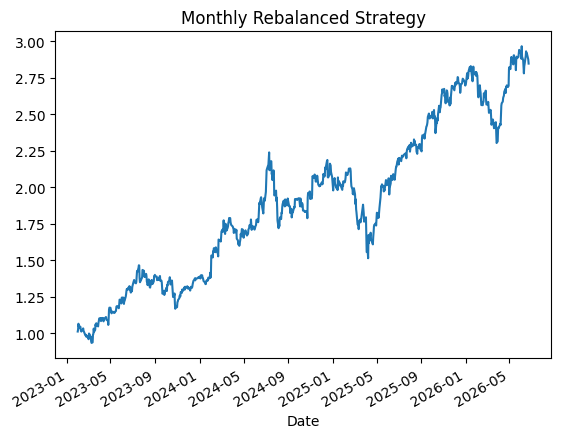

In [26]:
equity_curve = (

    1 + strategy_returns

).cumprod()

equity_curve.plot()

plt.title(
    "Monthly Rebalanced Strategy"
)

plt.show()

In [27]:
# ============================================
# PERFORMANCE METRICS
# ============================================

import numpy as np

# Annualization factor (daily data)
TRADING_DAYS = 252

# Strategy returns
r = strategy_returns

# CAGR
cagr = (1 + r).prod() ** (TRADING_DAYS / len(r)) - 1

# Volatility
vol = r.std() * np.sqrt(TRADING_DAYS)

# Sharpe Ratio (risk-free ~0 for simplicity)
sharpe = (r.mean() * TRADING_DAYS) / (r.std() * np.sqrt(TRADING_DAYS))

print("CAGR:", round(cagr, 4))
print("Volatility:", round(vol, 4))
print("Sharpe:", round(sharpe, 4))

CAGR: 0.363
Volatility: 0.2784
Sharpe: 1.2517


In [28]:
# ============================================
# MAX DRAWDOWN
# ============================================

equity = (1 + strategy_returns).cumprod()

rolling_max = equity.cummax()

drawdown = (equity - rolling_max) / rolling_max

max_drawdown = drawdown.min()

print("Max Drawdown:", round(max_drawdown, 4))

Max Drawdown: -0.3235


[*********************100%***********************]  1 of 1 completed


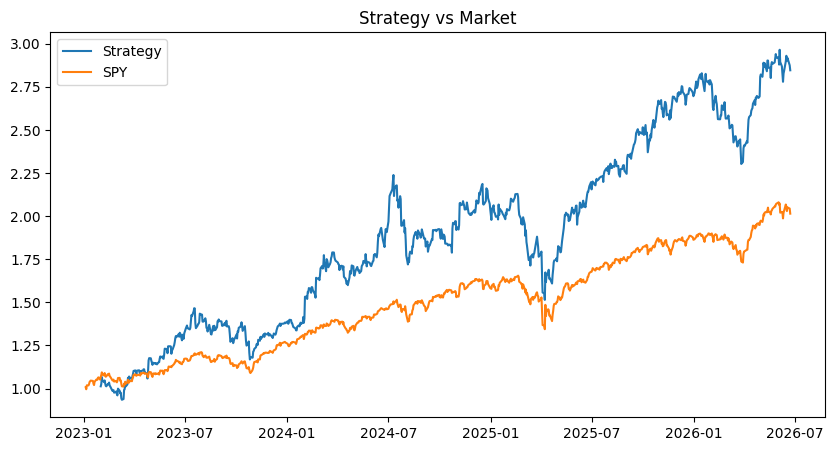

In [29]:
import yfinance as yf

spy = yf.download("SPY", start=prices.index[0])["Close"]
spy_returns = spy.pct_change().dropna()

spy_equity = (1 + spy_returns).cumprod()
strategy_equity = (1 + strategy_returns).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(strategy_equity, label="Strategy")
plt.plot(spy_equity, label="SPY")

plt.legend()
plt.title("Strategy vs Market")
plt.show()



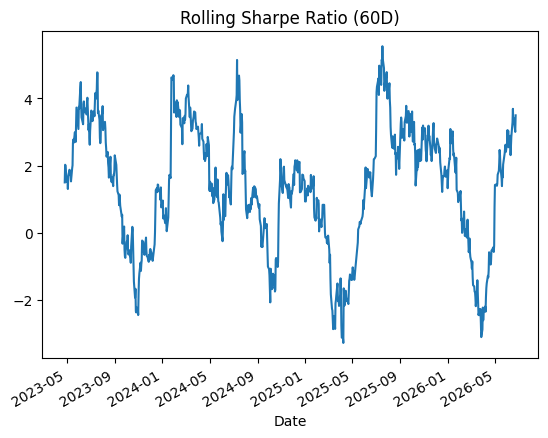

In [30]:
rolling_sharpe = (
    strategy_returns.rolling(60).mean()
    /
    strategy_returns.rolling(60).std()
) * np.sqrt(252)

rolling_sharpe.plot()

plt.title("Rolling Sharpe Ratio (60D)")
plt.show()

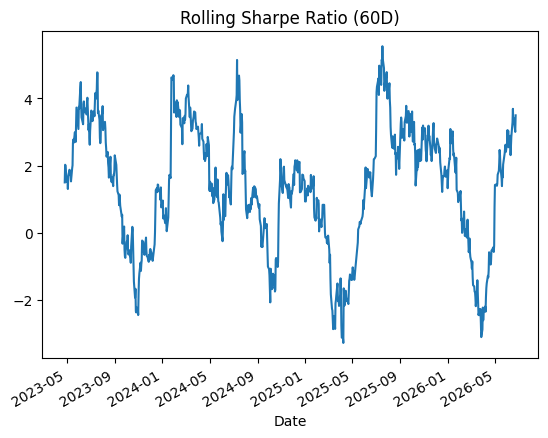

In [31]:
rolling_sharpe = (
    strategy_returns.rolling(60).mean()
    /
    strategy_returns.rolling(60).std()
) * np.sqrt(252)

rolling_sharpe.plot()

plt.title("Rolling Sharpe Ratio (60D)")
plt.show()

In [32]:
# ============================================
# TRANSACTION COST MODEL
# ============================================

TURNOVER_COST = 0.002  # 20 bps per trade (realistic assumption)

# approximate turnover = change in positions
turnover = strategy_returns.abs()

costs = turnover * TURNOVER_COST

net_returns = strategy_returns - costs

print("Avg Cost per Day:", costs.mean())

Avg Cost per Day: 2.528320302997608e-05


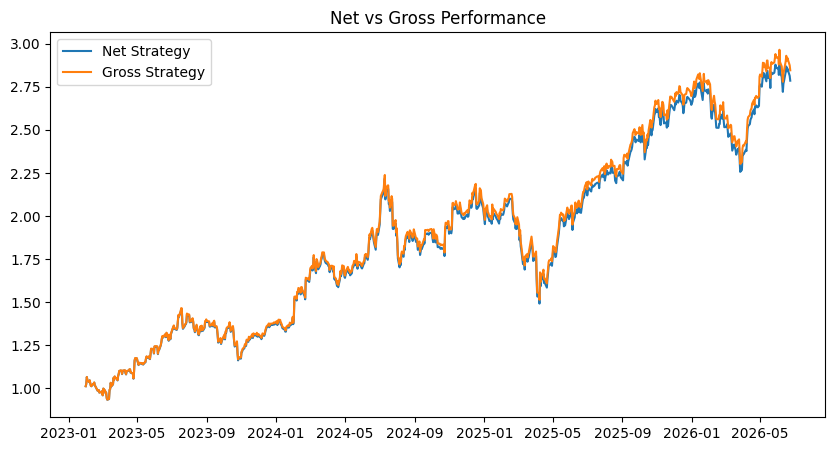

In [33]:
net_equity = (1 + net_returns).cumprod()

plt.figure(figsize=(10,5))
plt.plot(net_equity, label="Net Strategy")
plt.plot((1 + strategy_returns).cumprod(), label="Gross Strategy")

plt.legend()
plt.title("Net vs Gross Performance")
plt.show()

In [40]:
sector_exposure = pd.Series(0, index=["Tech","Auto","Financial","Other"])

for stock in top_stocks:
    sector = sector_map.get(stock, "Other")
    sector_exposure[sector] += 1

print(sector_exposure)

Tech         2
Auto         0
Financial    1
Other        0
dtype: int64


In [41]:
import numpy as np

r = strategy_returns.dropna()

sharpe = (r.mean() / r.std()) * np.sqrt(252)

print("Sharpe Ratio:", round(sharpe, 3))

Sharpe Ratio: 1.252


In [42]:
equity = (1 + r).cumprod()

rolling_max = equity.cummax()

drawdown = equity / rolling_max - 1

print("Max Drawdown:", round(drawdown.min(), 3))

Max Drawdown: -0.323


In [43]:
turnover = r.abs().mean()

print("Avg Turnover:", round(turnover, 4))

Avg Turnover: 0.0126


In [44]:
print("===================================")
print(" MOMENTUM FACTOR STRATEGY REPORT ")
print("===================================")

print("Sharpe Ratio:", round(sharpe, 3))
print("Max Drawdown:", round(drawdown.min(), 3))
print("Avg Daily Return:", round(r.mean(), 5))
print("Volatility:", round(r.std(), 5))
print("Avg Turnover:", round(turnover, 5))
print("Universe Size:", len(stocks))

 MOMENTUM FACTOR STRATEGY REPORT 
Sharpe Ratio: 1.252
Max Drawdown: -0.323
Avg Daily Return: 0.00138
Volatility: 0.01754
Avg Turnover: 0.01264
Universe Size: 10


[*********************100%***********************]  1 of 1 completed


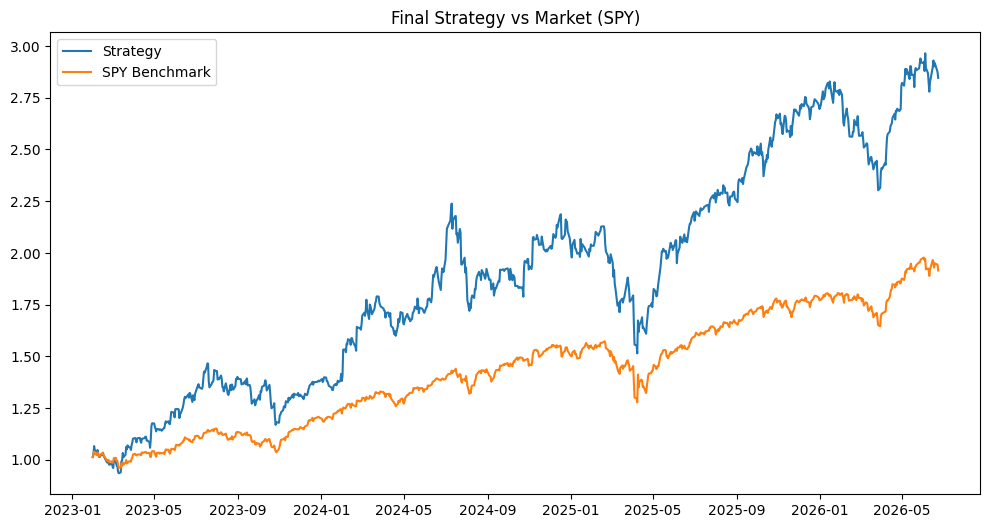

In [45]:
import yfinance as yf
import matplotlib.pyplot as plt

spy = yf.download("SPY", start=prices.index[0])["Close"]
spy_r = spy.pct_change().dropna()

strategy_eq = (1 + r).cumprod()
spy_eq = (1 + spy_r.loc[r.index]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(strategy_eq, label="Strategy")
plt.plot(spy_eq, label="SPY Benchmark")

plt.legend()
plt.title("Final Strategy vs Market (SPY)")
plt.show()